# Parte 3 – Cruce por ubigeo y análisis

**Assignment 2 – Scraping, APIs y cruce por ubigeo**
**Grupo 1 · Temporada asignada: 1 de enero al 31 de mayo de 2022**

**Pregunta del trabajo:** ¿El Estado declara emergencia donde más llueve?

En este notebook juntamos lo que salió de las dos partes anteriores:

| Insumo | De dónde viene | Qué trae |
|---|---|---|
| `datos/decretos_por_departamento.csv` | Parte 1 (scraping de gob.pe) | declaratorias y prórrogas por lluvias, por departamento |
| `datos/decretos_lluvias.csv` | Parte 1 | una fila por decreto de lluvias, con su `tipo` y su `motivo` |
| `datos/lluvias_por_departamento.csv` | Parte 2 (API de Open-Meteo) | lluvia total y días de lluvia fuerte en la capital de cada departamento |

Productos de este notebook:

- `datos/ubigeos.csv`
- `datos/tabla_final.csv`

El notebook usa rutas relativas, así que debe ejecutarse desde la carpeta `assignment_2/`.

In [1]:
import importlib.util
import unicodedata

import pandas as pd
import plotly.express as px

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

# Si está instalada la librería kaleido, además del gráfico interactivo mostramos una copia
# estática (PNG) para que el gráfico también se vea al abrir el notebook en GitHub.
# Si no está instalada, el notebook corre igual y solo muestra el gráfico interactivo.
HAY_KALEIDO = importlib.util.find_spec("kaleido") is not None
print("pandas", pd.__version__, "| copia estática de los gráficos:", HAY_KALEIDO)

pandas 3.0.6 | copia estática de los gráficos: True


## Paso 1. Crear `datos/ubigeos.csv`

Copiamos los 25 ubigeos departamentales del INEI tal como están en el enunciado. Los escribimos **entre comillas** (`"01"`, no `1`): el ubigeo es un código, no una cantidad, y el cero de la izquierda es parte del código.

In [2]:
ubigeos_inei = [
    ("01", "Amazonas"),      ("02", "Áncash"),        ("03", "Apurímac"),
    ("04", "Arequipa"),      ("05", "Ayacucho"),      ("06", "Cajamarca"),
    ("07", "Callao"),        ("08", "Cusco"),         ("09", "Huancavelica"),
    ("10", "Huánuco"),       ("11", "Ica"),           ("12", "Junín"),
    ("13", "La Libertad"),   ("14", "Lambayeque"),    ("15", "Lima"),
    ("16", "Loreto"),        ("17", "Madre de Dios"), ("18", "Moquegua"),
    ("19", "Pasco"),         ("20", "Piura"),         ("21", "Puno"),
    ("22", "San Martín"),    ("23", "Tacna"),         ("24", "Tumbes"),
    ("25", "Ucayali"),
]

ubigeos_df = pd.DataFrame(ubigeos_inei, columns=["ubigeo", "departamento"])
ubigeos_df.to_csv("datos/ubigeos.csv", index=False, encoding="utf-8-sig")

print("Filas:", len(ubigeos_df), "| ubigeos únicos:", ubigeos_df["ubigeo"].nunique(),
      "| departamentos únicos:", ubigeos_df["departamento"].nunique())
print("¿Todos los ubigeos tienen 2 caracteres?:", (ubigeos_df["ubigeo"].str.len() == 2).all())
print()
print("Así quedó escrito el archivo (primeras 4 líneas):")
with open("datos/ubigeos.csv", encoding="utf-8-sig") as archivo:
    for _ in range(4):
        print("  ", archivo.readline().strip())

Filas: 25 | ubigeos únicos: 25 | departamentos únicos: 25
¿Todos los ubigeos tienen 2 caracteres?: True

Así quedó escrito el archivo (primeras 4 líneas):
   ubigeo,departamento
   01,Amazonas
   02,Áncash
   03,Apurímac


## Paso 2. Leer el archivo dos veces: normal y con `dtype={"ubigeo": str}`

En el archivo el ubigeo está escrito como `01`. Lo leemos de las dos formas y comparamos.

In [3]:
ubigeos_numero = pd.read_csv("datos/ubigeos.csv", encoding="utf-8-sig")                         # lectura normal
ubigeos = pd.read_csv("datos/ubigeos.csv", encoding="utf-8-sig", dtype={"ubigeo": str})        # ubigeo como texto

print("Lectura normal            -> tipo de la columna ubigeo:", ubigeos_numero["ubigeo"].dtype)
print('Con dtype={"ubigeo": str} -> tipo de la columna ubigeo:', ubigeos["ubigeo"].dtype)
print()

comparacion = pd.DataFrame({
    "departamento": ubigeos["departamento"],
    "ubigeo_lectura_normal": ubigeos_numero["ubigeo"],
    "ubigeo_como_texto": ubigeos["ubigeo"],
})
comparacion["se_perdio_el_cero"] = comparacion["ubigeo_lectura_normal"].astype(str) != comparacion["ubigeo_como_texto"]
print("Departamentos que pierden el cero inicial con la lectura normal:",
      comparacion["se_perdio_el_cero"].sum(), "de", len(comparacion))
comparacion.head(11)

Lectura normal            -> tipo de la columna ubigeo: int64
Con dtype={"ubigeo": str} -> tipo de la columna ubigeo: str

Departamentos que pierden el cero inicial con la lectura normal: 9 de 25


,departamento,ubigeo_lectura_normal,ubigeo_como_texto,se_perdio_el_cero
0,Amazonas,1,01,True
1,Áncash,2,02,True
2,Apurímac,3,03,True
3,Arequipa,4,04,True
4,Ayacucho,5,05,True
5,Cajamarca,6,06,True
6,Callao,7,07,True
7,Cusco,8,08,True
8,Huancavelica,9,09,True
9,Huánuco,10,10,False


Dos consecuencias concretas de leer el ubigeo como número:

In [4]:
# 1) Un cruce entre una tabla con el ubigeo como número y otra con el ubigeo como texto no funciona
try:
    ubigeos_numero.merge(ubigeos, on="ubigeo")
    print("El cruce número vs. texto funcionó")
except ValueError as error:
    print("1) Error al cruzar número con texto:")
    print("  ", str(error).split(".")[0] + ".")

# 2) Aunque convirtamos el número a texto, el cero ya no vuelve solo: "1" no es igual a "01"
como_texto_despues = ubigeos_numero["ubigeo"].astype(str)
print()
print("2) Ubigeos que coinciden si convertimos el número a texto después de leer:",
      como_texto_despues.isin(ubigeos["ubigeo"]).sum(), "de", len(ubigeos))
print("   Los que ya no coinciden:", como_texto_despues[~como_texto_despues.isin(ubigeos["ubigeo"])].tolist())

# 3) Con el ubigeo de 6 dígitos de un distrito el error es peor: cambia de departamento
ubigeo_distrito = "010101"                  # distrito de Chachapoyas (Amazonas = 01)
como_numero = int(ubigeo_distrito)          # lo que haría la lectura normal
print()
print(f"3) Ubigeo de distrito {ubigeo_distrito!r} leído como número: {como_numero}")
print("   Sus dos primeros dígitos como texto:", ubigeo_distrito[:2], "->",
      ubigeos.loc[ubigeos["ubigeo"] == ubigeo_distrito[:2], "departamento"].iloc[0])
print("   Sus dos primeros dígitos como número:", str(como_numero)[:2], "->",
      ubigeos.loc[ubigeos["ubigeo"] == str(como_numero)[:2], "departamento"].iloc[0])

1) Error al cruzar número con texto:
   You are trying to merge on int64 and str columns for key 'ubigeo'.

2) Ubigeos que coinciden si convertimos el número a texto después de leer: 16 de 25
   Los que ya no coinciden: ['1', '2', '3', '4', '5', '6', '7', '8', '9']

3) Ubigeo de distrito '010101' leído como número: 10101
   Sus dos primeros dígitos como texto: 01 -> Amazonas
   Sus dos primeros dígitos como número: 10 -> Huánuco


**¿Cuál es la diferencia y por qué importa?**

- Con la lectura normal, pandas ve que la columna solo tiene dígitos y la convierte en **número entero**. Como número, `01` es `1`: **el cero de la izquierda se pierde**. Pasa en 9 de los 25 departamentos (del `01` al `09`: Amazonas, Áncash, Apurímac, Arequipa, Ayacucho, Cajamarca, Callao, Cusco y Huancavelica). Con `dtype={"ubigeo": str}` la columna se lee como **texto** y queda igual que en el archivo.
- El ubigeo **no es una cantidad, es un código** (como un DNI o un número de teléfono): no tiene sentido sumarlo ni promediarlo, y sí importa cada carácter, incluido el cero.
- Importa porque el ubigeo es **la llave con la que cruzamos las tablas**:
  1. Si una tabla lo tiene como número y otra como texto, `merge` da error (lo vimos arriba) o, si se convierten mal, **no encuentra pareja**: `"1"` no es igual a `"01"`. Esos 9 departamentos se quedarían sin datos en el cruce sin que salga ningún aviso.
  2. En los ubigeos de provincia y distrito (6 dígitos) los dos primeros son el departamento. Sin el cero, `010101` (Chachapoyas, Amazonas) pasa a ser `10101`, y sus dos primeros dígitos dirían `10`, que es **Huánuco**: el dato se iría a otro departamento.
  3. El enunciado pide guardar el ubigeo como texto de 2 dígitos (`01`). Si lo dejamos como número, el archivo final saldría con `1`.

Por eso, desde aquí usamos solo la tabla `ubigeos` leída con `dtype={"ubigeo": str}`, y cada vez que leamos un archivo que tenga ubigeo lo leeremos así.

## Paso 3. Agregar el `ubigeo` a las dos tablas

Leemos los archivos de la Parte 1 y de la Parte 2. Esas tablas todavía no tienen ubigeo: solo tienen el **nombre** del departamento. Por eso este primer cruce (y solo este) se hace por nombre, con `how="left"` para conservar todas las filas de cada tabla aunque alguna no encuentre su ubigeo. Así las que no lo encuentren quedan a la vista (con el ubigeo vacío) en lugar de desaparecer.

In [5]:
decretos = pd.read_csv("datos/decretos_por_departamento.csv", encoding="utf-8-sig")
lluvias = pd.read_csv("datos/lluvias_por_departamento.csv", encoding="utf-8-sig")

print("decretos_por_departamento.csv:", decretos.shape, "->", decretos.columns.tolist())
print("lluvias_por_departamento.csv: ", lluvias.shape, "->", lluvias.columns.tolist())

decretos_u = decretos.merge(ubigeos, on="departamento", how="left")
lluvias_u = lluvias.merge(ubigeos, on="departamento", how="left")

print()
print("Filas antes y después de agregar el ubigeo (deben ser iguales):")
print("  decretos:", len(decretos), "->", len(decretos_u))
print("  lluvias: ", len(lluvias), "->", len(lluvias_u))

decretos_por_departamento.csv: (25, 3) -> ['departamento', 'declaratorias', 'prorrogas']
lluvias_por_departamento.csv:  (25, 6) -> ['departamento', 'capital', 'latitud', 'longitud', 'lluvia_total_mm', 'dias_lluvia_fuerte']

Filas antes y después de agregar el ubigeo (deben ser iguales):
  decretos: 25 -> 25
  lluvias:  25 -> 25


In [6]:
decretos_u.head()

,departamento,declaratorias,prorrogas,ubigeo
0,Amazonas,1,0,01
1,Áncash,0,0,02
2,Apurímac,0,0,03
3,Arequipa,0,0,04
4,Ayacucho,1,0,05


In [7]:
lluvias_u.head()

,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,ubigeo
0,Amazonas,Chachapoyas,-6.23169,-77.86903,436.5,1,01
1,Áncash,Huaraz,-9.52614,-77.52869,975.3,7,02
2,Apurímac,Abancay,-13.63426,-72.88380,711.8,2,03
3,Arequipa,Arequipa,-16.39899,-71.53747,189.9,0,04
4,Ayacucho,Ayacucho,-13.16380,-74.22345,485.1,0,05


## Paso 4. Verificación: ¿qué departamentos no encontraron su ubigeo?

Para cada tabla revisamos tres cosas:

1. qué filas quedaron **sin ubigeo** (el nombre no está escrito igual que en `ubigeos.csv`);
2. qué ubigeos oficiales **no aparecen** en la tabla (un departamento que falta);
3. si algún ubigeo quedó **repetido** (el mismo departamento dos veces).

In [8]:
def revisar_ubigeos(tabla, nombre_tabla):
    # Muestra qué departamentos de la tabla no encontraron ubigeo y qué ubigeos no se usaron
    sin_ubigeo = tabla.loc[tabla["ubigeo"].isna(), "departamento"].tolist()
    no_usados = ubigeos.loc[~ubigeos["ubigeo"].isin(tabla["ubigeo"]), "departamento"].tolist()
    repetidos = tabla.loc[tabla["ubigeo"].notna() & tabla["ubigeo"].duplicated(keep=False), "departamento"].tolist()
    print(f"{nombre_tabla}: {len(tabla)} filas")
    print(f"   departamentos SIN ubigeo:            {len(sin_ubigeo)} {sin_ubigeo}")
    print(f"   ubigeos oficiales que no aparecen:   {len(no_usados)} {no_usados}")
    print(f"   departamentos con ubigeo repetido:   {len(repetidos)} {repetidos}")
    return sin_ubigeo


faltan_decretos = revisar_ubigeos(decretos_u, "decretos_por_departamento")
print()
faltan_lluvias = revisar_ubigeos(lluvias_u, "lluvias_por_departamento")

decretos_por_departamento: 25 filas
   departamentos SIN ubigeo:            0 []
   ubigeos oficiales que no aparecen:   0 []
   departamentos con ubigeo repetido:   0 []

lluvias_por_departamento: 25 filas
   departamentos SIN ubigeo:            0 []
   ubigeos oficiales que no aparecen:   0 []
   departamentos con ubigeo repetido:   0 []


**Resultado:** en nuestras dos tablas **no quedó ningún departamento sin ubigeo**. Los 25 nombres de cada archivo están escritos exactamente igual que en la tabla del INEI (con sus tildes: Áncash, Apurímac, Huánuco, Junín, San Martín), no falta ningún departamento y ninguno está repetido.

No es casualidad. En la Parte 1 los departamentos se buscaron en los títulos con la misma lista del enunciado, y en la Parte 2 los nombres de Wikipedia se compararon contra esa misma lista (ahí se detectó que faltaba el Callao y se agregó). Por eso no tuvimos nada que corregir.

Pero que la tabla de "no encontrados" salga vacía solo vale si la verificación **de verdad detecta** los problemas. Para comprobarlo la probamos con una tabla de prueba (inventada, **no son nuestros datos**) con los errores típicos: sin tilde, en mayúsculas, con un espacio de más y con otra grafía.

In [9]:
prueba = pd.DataFrame({"departamento": ["Ancash", "MADRE DE DIOS", "San Martín ", "Cuzco", "Piura"]})

prueba_u = prueba.merge(ubigeos, on="departamento", how="left")
print("Cruce directo por nombre (sin corregir nada):")
print(prueba_u.to_string(index=False))
print("\nNo encontraron ubigeo:", prueba_u.loc[prueba_u["ubigeo"].isna(), "departamento"].tolist())

Cruce directo por nombre (sin corregir nada):
 departamento ubigeo
       Ancash    NaN
MADRE DE DIOS    NaN
  San Martín     NaN
        Cuzco    NaN
        Piura     20

No encontraron ubigeo: ['Ancash', 'MADRE DE DIOS', 'San Martín ', 'Cuzco']


La verificación sí los detecta: solo `Piura` encontró su ubigeo. Así los corregiríamos:

- **Tildes, mayúsculas y espacios:** comparamos con una "clave" del nombre (en minúsculas, sin tildes y sin espacios sobrantes), sin cambiar el nombre oficial.
- **Nombres escritos distinto** (por ejemplo `Cuzco`): no se arreglan con una regla general, así que van en un diccionario de correcciones escrito a mano, para que quede a la vista cada cambio que hicimos.

In [10]:
def clave(nombre):
    # Nombre en minúsculas, sin tildes y sin espacios sobrantes. Solo sirve para comparar.
    texto = unicodedata.normalize("NFD", str(nombre))
    texto = "".join(letra for letra in texto if unicodedata.category(letra) != "Mn")   # quita las tildes
    return " ".join(texto.lower().split())


# Nombres que no se arreglan quitando tildes: {clave del nombre mal escrito: nombre oficial}
CORRECCIONES = {"cuzco": "Cusco"}


def agregar_ubigeo(tabla):
    # Agrega el ubigeo comparando por la clave del nombre y usando las correcciones manuales
    ubigeo_por_clave = dict(zip(ubigeos["departamento"].apply(clave), ubigeos["ubigeo"]))
    claves = tabla["departamento"].apply(clave)
    claves = claves.apply(lambda c: clave(CORRECCIONES[c]) if c in CORRECCIONES else c)
    resultado = tabla.copy()
    resultado["ubigeo"] = claves.map(ubigeo_por_clave)
    return resultado


prueba_corregida = agregar_ubigeo(prueba)
print(prueba_corregida.to_string(index=False))
print("\nNo encontraron ubigeo después de corregir:",
      prueba_corregida.loc[prueba_corregida["ubigeo"].isna(), "departamento"].tolist())

 departamento ubigeo
       Ancash     02
MADRE DE DIOS     17
  San Martín      22
        Cuzco     08
        Piura     20

No encontraron ubigeo después de corregir: []


Con la corrección, los 5 nombres de la prueba encuentran su ubigeo. Ahora aplicamos **la misma función a nuestras dos tablas reales** y comprobamos que da exactamente los mismos ubigeos que el cruce directo. Si en otra temporada (o si se vuelve a correr la Parte 1 o la Parte 2) algún nombre llegara escrito distinto, esta celda lo resolvería o se detendría con un mensaje.

In [11]:
decretos_u2 = agregar_ubigeo(decretos)
lluvias_u2 = agregar_ubigeo(lluvias)

print("¿La función da los mismos ubigeos que el cruce directo?")
print("   decretos:", decretos_u2["ubigeo"].equals(decretos_u["ubigeo"]))
print("   lluvias: ", lluvias_u2["ubigeo"].equals(lluvias_u["ubigeo"]))

# Si quedara algún departamento sin ubigeo, el notebook se detiene aquí
assert len(faltan_decretos) == 0 and decretos_u["ubigeo"].notna().all(), "Hay departamentos sin ubigeo en decretos"
assert len(faltan_lluvias) == 0 and lluvias_u["ubigeo"].notna().all(), "Hay departamentos sin ubigeo en lluvias"
assert decretos_u["ubigeo"].is_unique and lluvias_u["ubigeo"].is_unique, "Hay ubigeos repetidos"
print("\nOK: las dos tablas tienen sus 25 departamentos con ubigeo, sin repetidos y sin ninguno pendiente.")

¿La función da los mismos ubigeos que el cruce directo?
   decretos: True
   lluvias:  True

OK: las dos tablas tienen sus 25 departamentos con ubigeo, sin repetidos y sin ninguno pendiente.


## Paso 5. Cruzar las dos tablas por `ubigeo`

Ahora que las dos tablas tienen ubigeo, el cruce se hace **por `ubigeo` y no por nombre**. El nombre puede venir escrito de varias formas (lo vimos en la prueba del paso 4); el ubigeo es uno solo para cada departamento.

Decisiones del cruce:

- Partimos de la tabla de lluvias, que tiene los 25 departamentos, y usamos `how="left"`. Así **un departamento sin decretos no desaparece**: se queda en la tabla con las columnas de decretos vacías, y después las llenamos con 0.
- De la tabla de decretos traemos solo `ubigeo`, `declaratorias` y `prorrogas` (no su columna `departamento`, para no tener el nombre dos veces).
- `validate="one_to_one"` hace que pandas dé error si algún ubigeo estuviera repetido en alguna de las dos tablas (se duplicarían filas).
- `indicator=True` agrega la columna `_merge`, que dice si cada fila encontró pareja (`both`) o no (`left_only`).

In [12]:
cruce = lluvias_u.merge(
    decretos_u[["ubigeo", "declaratorias", "prorrogas"]],
    on="ubigeo", how="left", validate="one_to_one", indicator=True,
)

print("Filas del cruce:", len(cruce))
print()
print("¿Cada departamento encontró su pareja en la tabla de decretos?")
print(cruce["_merge"].value_counts().to_string())
print()
print("Valores vacíos en declaratorias:", cruce["declaratorias"].isna().sum(), "| en prorrogas:", cruce["prorrogas"].isna().sum())

Filas del cruce: 25

¿Cada departamento encontró su pareja en la tabla de decretos?
_merge
both          25
left_only      0
right_only     0

Valores vacíos en declaratorias: 0 | en prorrogas: 0


Los 25 departamentos encontraron pareja (`both`) y no quedó ningún valor vacío. Esto pasa porque el archivo de la Parte 1 **ya trae los 25 departamentos**, con 0 en los que no tuvieron decretos.

Igual llenamos los vacíos con 0 (`fillna(0)`), para que el cruce no dependa de eso: si la tabla de decretos trajera solo los departamentos que sí tuvieron decretos, los demás quedarían vacíos (`NaN`) y aquí se convertirían en 0. **Solo llenamos con 0 las columnas de decretos**: no encontrar un decreto significa "0 decretos". En cambio, **no** llenaríamos con 0 una lluvia vacía, porque "sin dato de lluvia" no es lo mismo que "0 mm".

In [13]:
for columna in ["declaratorias", "prorrogas"]:
    cruce[columna] = cruce[columna].fillna(0).astype(int)

tabla_final = (cruce[["ubigeo", "departamento", "capital", "latitud", "longitud",
                      "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias", "prorrogas"]]
               .sort_values("ubigeo")
               .reset_index(drop=True))
tabla_final

,ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,01,Amazonas,Chachapoyas,-6.23169,-77.86903,436.5,1,1,0
1,02,Áncash,Huaraz,-9.52614,-77.52869,975.3,7,0,0
2,03,Apurímac,Abancay,-13.63426,-72.88380,711.8,2,0,0
3,04,Arequipa,Arequipa,-16.39899,-71.53747,189.9,0,0,0
4,05,Ayacucho,Ayacucho,-13.16380,-74.22345,485.1,0,1,0
5,06,Cajamarca,Cajamarca,-7.16378,-78.50027,773.3,1,0,0
6,07,Callao,Callao,-12.05162,-77.13452,39.2,0,0,0
7,08,Cusco,Cusco,-13.53188,-71.96701,710.7,3,0,0
8,09,Huancavelica,Huancavelica,-12.78691,-74.97298,803.8,1,0,0
9,10,Huánuco,Huánuco,-9.92882,-76.23989,444.8,1,0,0


**¿Qué habría pasado con otro tipo de cruce?** Lo comprobamos con una simulación: nos quedamos solo con los departamentos que sí tienen decretos (como si la tabla de la Parte 1 no trajera los ceros) y cruzamos de dos formas.

In [14]:
solo_con_decretos = decretos_u.loc[(decretos_u["declaratorias"] + decretos_u["prorrogas"]) > 0,
                                   ["ubigeo", "declaratorias", "prorrogas"]]
print("Departamentos con al menos un decreto:", len(solo_con_decretos))

cruce_inner = lluvias_u.merge(solo_con_decretos, on="ubigeo", how="inner")
cruce_left = lluvias_u.merge(solo_con_decretos, on="ubigeo", how="left")
cruce_left["declaratorias"] = cruce_left["declaratorias"].fillna(0).astype(int)

print('Con how="inner":             ', len(cruce_inner), "filas -> desaparecen", len(lluvias_u) - len(cruce_inner), "departamentos")
print('Con how="left" y fillna(0):  ', len(cruce_left), "filas ->", (cruce_left["declaratorias"] == 0).sum(), "departamentos con 0 declaratorias")

Departamentos con al menos un decreto: 3
Con how="inner":              3 filas -> desaparecen 22 departamentos
Con how="left" y fillna(0):   25 filas -> 22 departamentos con 0 declaratorias


Con `how="inner"` solo quedarían 3 departamentos y habríamos perdido justo a los que no tuvieron declaratorias, que son la mitad de la respuesta a la pregunta del trabajo (dónde llovió y **no** se declaró emergencia). Con `how="left"` y `fillna(0)` se mantienen los 25.

## Paso 6. Verificación de la tabla final

La tabla final debe tener **25 filas**, y los departamentos sin declaratorias deben estar con **0**. Además comprobamos que el cruce no haya cambiado ningún número respecto de los archivos originales.

In [15]:
print("Filas de la tabla final:", len(tabla_final), "(esperadas: 25)")
print("Ubigeos únicos:", tabla_final["ubigeo"].nunique())
print("¿Son exactamente los 25 ubigeos del INEI?:", set(tabla_final["ubigeo"]) == set(ubigeos["ubigeo"]))
print("Valores vacíos en toda la tabla:", int(tabla_final.isna().sum().sum()))
print()
print("Departamentos con 0 declaratorias:", (tabla_final["declaratorias"] == 0).sum())
print("Departamentos con 1 o más declaratorias:", (tabla_final["declaratorias"] > 0).sum(),
      "->", tabla_final.loc[tabla_final["declaratorias"] > 0, "departamento"].tolist())
print()
print("Suma de declaratorias: tabla final =", tabla_final["declaratorias"].sum(), "| archivo de la Parte 1 =", decretos["declaratorias"].sum())
print("Suma de prórrogas:     tabla final =", tabla_final["prorrogas"].sum(), "| archivo de la Parte 1 =", decretos["prorrogas"].sum())
print("Suma de lluvia (mm):   tabla final =", round(tabla_final["lluvia_total_mm"].sum(), 1), "| archivo de la Parte 2 =", round(lluvias["lluvia_total_mm"].sum(), 1))

# ¿Cada departamento conserva sus propios números? Comparamos por nombre contra los archivos originales
original = decretos.merge(lluvias, on="departamento")
comparado = tabla_final.merge(original, on="departamento", suffixes=("", "_original"))
iguales = all((comparado[c] == comparado[c + "_original"]).all()
              for c in ["declaratorias", "prorrogas", "lluvia_total_mm", "dias_lluvia_fuerte"])
print("¿Cada departamento conserva los números de sus archivos originales?:", iguales)

assert len(tabla_final) == 25 and tabla_final["ubigeo"].nunique() == 25
assert tabla_final.isna().sum().sum() == 0
assert tabla_final["declaratorias"].sum() == decretos["declaratorias"].sum()
assert iguales
print("\nOK: 25 filas, sin vacíos, y los departamentos sin declaratoria aparecen con 0.")

Filas de la tabla final: 25 (esperadas: 25)
Ubigeos únicos: 25
¿Son exactamente los 25 ubigeos del INEI?: True
Valores vacíos en toda la tabla: 0

Departamentos con 0 declaratorias: 22
Departamentos con 1 o más declaratorias: 3 -> ['Amazonas', 'Ayacucho', 'Piura']

Suma de declaratorias: tabla final = 3 | archivo de la Parte 1 = 3
Suma de prórrogas:     tabla final = 0 | archivo de la Parte 1 = 0
Suma de lluvia (mm):   tabla final = 13290.2 | archivo de la Parte 2 = 13290.2
¿Cada departamento conserva los números de sus archivos originales?: True

OK: 25 filas, sin vacíos, y los departamentos sin declaratoria aparecen con 0.


## Paso 7. Guardar `datos/tabla_final.csv`

Guardamos con `encoding="utf-8-sig"`, igual que los archivos de las Partes 1 y 2, para que las tildes se vean bien en Excel. Después **volvemos a leer el archivo** para comprobar que el ubigeo quedó como texto de 2 dígitos.

In [16]:
tabla_final.to_csv("datos/tabla_final.csv", index=False, encoding="utf-8-sig")

print("Primeras líneas del archivo guardado:")
with open("datos/tabla_final.csv", encoding="utf-8-sig") as archivo:
    for _ in range(4):
        print("  ", archivo.readline().strip())

leida = pd.read_csv("datos/tabla_final.csv", encoding="utf-8-sig", dtype={"ubigeo": str})
print()
print("Archivo: datos/tabla_final.csv ->", leida.shape, "| columnas:", leida.columns.tolist())
print("¿Todos los ubigeos tienen 2 caracteres?:", (leida["ubigeo"].str.len() == 2).all())
print("Primeros ubigeos:", leida["ubigeo"].head(10).tolist())
print("¿El archivo leído es igual a la tabla en memoria?:", leida.equals(tabla_final))

Primeras líneas del archivo guardado:
   ubigeo,departamento,capital,latitud,longitud,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
   01,Amazonas,Chachapoyas,-6.23169,-77.86903,436.5,1,1,0
   02,Áncash,Huaraz,-9.52614,-77.52869,975.3,7,0,0
   03,Apurímac,Abancay,-13.63426,-72.8838,711.8,2,0,0

Archivo: datos/tabla_final.csv -> (25, 9) | columnas: ['ubigeo', 'departamento', 'capital', 'latitud', 'longitud', 'lluvia_total_mm', 'dias_lluvia_fuerte', 'declaratorias', 'prorrogas']
¿Todos los ubigeos tienen 2 caracteres?: True
Primeros ubigeos: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']
¿El archivo leído es igual a la tabla en memoria?: True


En el archivo el ubigeo está escrito como `01`, `02`, … Ojo: para que siga siendo texto **al leerlo**, hay que usar otra vez `dtype={"ubigeo": str}`. Si se lee con `pd.read_csv` normal, pandas lo vuelve a convertir en número (paso 2).

## Paso 8. Gráficos con Plotly

Como en la Sesión 6, usamos **Plotly Express**: un DataFrame, y se indica qué columna va en cada eje. Los gráficos son interactivos: al pasar el mouse sobre un punto o una barra aparecen los datos del departamento.

Antes de graficar ordenamos los departamentos por lluvia, para tener a la mano el puesto de cada uno (1 = donde más llovió).

In [17]:
# method="min": si dos departamentos empataran en lluvia, compartirían el mismo puesto
tabla_final["puesto_lluvia"] = tabla_final["lluvia_total_mm"].rank(ascending=False, method="min").astype(int)

ranking = tabla_final.sort_values("lluvia_total_mm", ascending=False)
ranking[["puesto_lluvia", "ubigeo", "departamento", "capital", "lluvia_total_mm", "dias_lluvia_fuerte", "declaratorias", "prorrogas"]].reset_index(drop=True)

,puesto_lluvia,ubigeo,departamento,capital,lluvia_total_mm,dias_lluvia_fuerte,declaratorias,prorrogas
0,1,16,Loreto,Iquitos,1581.8,25,0,0
1,2,25,Ucayali,Pucallpa,1288.8,20,0,0
2,3,02,Áncash,Huaraz,975.3,7,0,0
3,4,12,Junín,Huancayo,910.4,5,0,0
4,5,17,Madre de Dios,Puerto Maldonado,908.0,13,0,0
5,6,09,Huancavelica,Huancavelica,803.8,1,0,0
6,7,22,San Martín,Moyobamba,789.8,4,0,0
7,8,21,Puno,Puno,779.5,3,0,0
8,9,19,Pasco,Cerro de Pasco,774.0,0,0,0
9,10,06,Cajamarca,Cajamarca,773.3,1,0,0


In [18]:
FUENTE = ("Fuente: gob.pe (normas de la PCM, enero-mayo de 2022) y Open-Meteo (lluvia diaria en la capital "
          "de cada departamento). Elaboración propia.")
COLORES = {"Con declaratoria": "#C0392B", "Sin declaratoria": "#7F8C8D"}


def mostrar(fig):
    fig.show()                        # gráfico interactivo (VS Code, Jupyter)
    if HAY_KALEIDO:
        try:
            fig.show(renderer="png")  # copia estática, para que también se vea en GitHub
        except Exception as error:    # kaleido necesita Chrome; si no lo encuentra, seguimos sin la copia
            print("No se pudo generar la copia estática del gráfico:", type(error).__name__)


def poner_fuente(fig, y=-0.2):
    fig.add_annotation(text=FUENTE, showarrow=False, xref="paper", yref="paper",
                       x=0, y=y, xanchor="left", font=dict(size=11, color="gray"))

### Gráfico 1. Dispersión: lluvia total vs. declaratorias

`lluvia_total_mm` va en el eje X y `declaratorias` en el eje Y. Como en nuestra temporada las declaratorias solo valen 0 o 1, los puntos quedan en dos filas. Hay 22 departamentos en la fila del 0 y varios con lluvias muy parecidas, así que si ponemos el nombre pegado a cada punto se enciman. Por eso cada nombre va unido a su punto con una línea delgada y a una altura distinta (se alternan arriba y abajo).

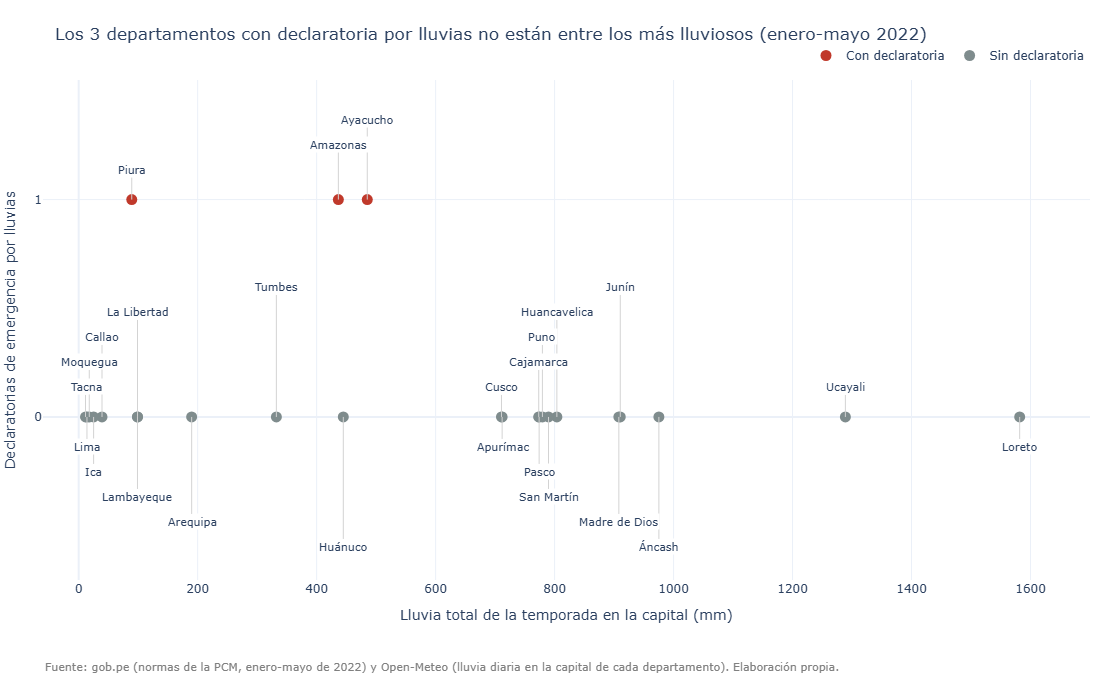

In [19]:
datos_grafico = tabla_final.copy()
datos_grafico["grupo"] = datos_grafico["declaratorias"].apply(
    lambda n: "Con declaratoria" if n > 0 else "Sin declaratoria")

fig = px.scatter(
    datos_grafico, x="lluvia_total_mm", y="declaratorias",
    color="grupo", color_discrete_map=COLORES,
    hover_name="departamento",
    hover_data={"capital": True, "puesto_lluvia": True, "dias_lluvia_fuerte": True, "grupo": False},
    title="Los 3 departamentos con declaratoria por lluvias no están entre los más lluviosos (enero-mayo 2022)",
    labels={"lluvia_total_mm": "Lluvia total de la temporada en la capital (mm)",
            "declaratorias": "Declaratorias de emergencia por lluvias",
            "grupo": "", "capital": "Capital", "puesto_lluvia": "Puesto en lluvia",
            "dias_lluvia_fuerte": "Días con 20 mm o más"},
)
fig.update_traces(marker=dict(size=11))

# Nombre del departamento en cada punto. La distancia (en píxeles) entre el punto y su nombre
# va cambiando de un punto al siguiente para que los nombres no se encimen. Negativo = arriba.
distancias = {
    0: [-30, 30, -55, 55, -80, 80, -105, 105, -130, 130],   # fila de 0 declaratorias: arriba y abajo
    1: [-30, -55, -80],                                      # fila de 1 declaratoria: solo arriba
}
etiquetas = []
for valor, fila_puntos in datos_grafico.sort_values("lluvia_total_mm").groupby("declaratorias"):
    opciones = distancias[0] if valor == 0 else distancias[1]
    for i, punto in enumerate(fila_puntos.itertuples()):
        etiquetas.append((punto.lluvia_total_mm, punto.declaratorias, punto.departamento, opciones[i % len(opciones)]))

# Primero se dibujan los nombres más alejados; los cercanos tapan las líneas que pasan por detrás
for x, y, nombre, distancia in sorted(etiquetas, key=lambda e: -abs(e[3])):
    fig.add_annotation(x=x, y=y, text=nombre, ax=0, ay=distancia,
                       showarrow=True, arrowhead=0, arrowwidth=1, arrowcolor="lightgray",
                       font=dict(size=11), bgcolor="white", borderpad=1)

fig.update_yaxes(range=[-0.75, 1.55], tickvals=[0, 1])
fig.update_xaxes(range=[-60, 1700])
fig.update_layout(template="plotly_white", width=1100, height=680, title_font_size=17,
                  legend=dict(orientation="h", x=1, xanchor="right", y=1.02, yanchor="bottom"),
                  margin=dict(l=10, r=10, t=80, b=100))
poner_fuente(fig, y=-0.19)
mostrar(fig)

### Gráfico 2. Barras: los 10 departamentos con más declaratorias

Hay que tomar una decisión antes de graficar: **solo 3 departamentos tienen declaratorias** (1 cada uno) y los otros 22 están empatados en 0. No existe un "top 10" real. Para completar los 10 que pide el enunciado desempatamos por **lluvia total**: después de los 3 con declaratoria van los 7 departamentos más lluviosos, todos con 0. Lo decimos en el gráfico para que nadie lea que esos 7 tuvieron "más declaratorias" que los otros 15.

Departamentos empatados en 0 declaratorias: 22 (en el gráfico entran 7)
ubigeo  departamento  declaratorias  prorrogas  lluvia_total_mm  puesto_lluvia
    05      Ayacucho              1          0            485.1             13
    01      Amazonas              1          0            436.5             15
    20         Piura              1          0             89.2             20
    16        Loreto              0          0           1581.8              1
    25       Ucayali              0          0           1288.8              2
    02        Áncash              0          0            975.3              3
    12         Junín              0          0            910.4              4
    17 Madre de Dios              0          0            908.0              5
    09  Huancavelica              0          0            803.8              6
    22    San Martín              0          0            789.8              7


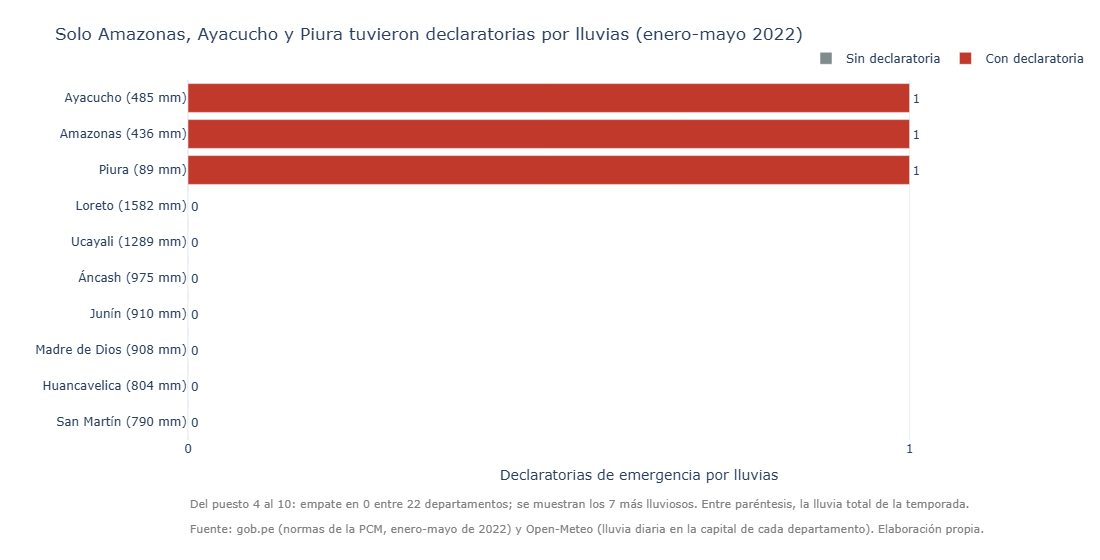

In [20]:
orden_top = tabla_final.sort_values(["declaratorias", "lluvia_total_mm"], ascending=[False, False])
top10 = orden_top.head(10).copy()
top10["grupo"] = top10["declaratorias"].apply(lambda n: "Con declaratoria" if n > 0 else "Sin declaratoria")
top10["etiqueta"] = top10["departamento"] + " (" + top10["lluvia_total_mm"].round(0).astype(int).astype(str) + " mm)"

print("Departamentos empatados en 0 declaratorias:", (tabla_final["declaratorias"] == 0).sum(), "(en el gráfico entran 7)")
print(top10[["ubigeo", "departamento", "declaratorias", "prorrogas", "lluvia_total_mm", "puesto_lluvia"]].to_string(index=False))

fig = px.bar(
    top10.iloc[::-1],                 # al revés, para que el primero quede arriba en las barras horizontales
    x="declaratorias", y="etiqueta", orientation="h",
    color="grupo", color_discrete_map=COLORES, text="declaratorias",
    hover_name="departamento",
    hover_data={"lluvia_total_mm": True, "puesto_lluvia": True, "etiqueta": False, "grupo": False},
    title="Solo Amazonas, Ayacucho y Piura tuvieron declaratorias por lluvias (enero-mayo 2022)",
    labels={"declaratorias": "Declaratorias de emergencia por lluvias", "etiqueta": "", "grupo": "",
            "lluvia_total_mm": "Lluvia total (mm)", "puesto_lluvia": "Puesto en lluvia"},
)
fig.update_traces(textposition="outside", cliponaxis=False)
fig.update_xaxes(range=[0, 1.25], dtick=1)
fig.update_yaxes(categoryorder="array", categoryarray=top10["etiqueta"].iloc[::-1].tolist())
fig.update_layout(template="plotly_white", width=1100, height=560, title_font_size=17,
                  legend=dict(orientation="h", x=1, xanchor="right", y=1.02, yanchor="bottom"),
                  margin=dict(l=10, r=10, t=80, b=120))
fig.add_annotation(text="Del puesto 4 al 10: empate en 0 entre 22 departamentos; se muestran los 7 más lluviosos. "
                        "Entre paréntesis, la lluvia total de la temporada.",
                   showarrow=False, xref="paper", yref="paper", x=0, y=-0.2, xanchor="left",
                   font=dict(size=11, color="gray"))
poner_fuente(fig, y=-0.27)
mostrar(fig)

## Paso 9. Preguntas de análisis

Primero calculamos, en una sola celda, los números que usamos en las respuestas.

In [21]:
con_declaratoria = tabla_final[tabla_final["declaratorias"] > 0]
sin_declaratoria = tabla_final[tabla_final["declaratorias"] == 0]

print("TOP 3 POR DECLARATORIAS")
print(orden_top.head(3)[["departamento", "declaratorias", "lluvia_total_mm", "puesto_lluvia", "dias_lluvia_fuerte"]].to_string(index=False))
print("\nTOP 3 POR LLUVIA")
print(ranking.head(3)[["departamento", "declaratorias", "lluvia_total_mm", "puesto_lluvia", "dias_lluvia_fuerte"]].to_string(index=False))

top3_declaratorias = set(orden_top.head(3)["departamento"])
top3_lluvia = set(ranking.head(3)["departamento"])
print("\nDepartamentos que están en los dos top 3:", sorted(top3_declaratorias & top3_lluvia))

print("\nLLUVIA TOTAL (mm) SEGÚN SI HUBO DECLARATORIA")
resumen = pd.DataFrame({
    "departamentos": [len(con_declaratoria), len(sin_declaratoria), len(tabla_final)],
    "promedio_mm": [con_declaratoria["lluvia_total_mm"].mean(), sin_declaratoria["lluvia_total_mm"].mean(), tabla_final["lluvia_total_mm"].mean()],
    "mediana_mm": [con_declaratoria["lluvia_total_mm"].median(), sin_declaratoria["lluvia_total_mm"].median(), tabla_final["lluvia_total_mm"].median()],
}, index=["Con declaratoria", "Sin declaratoria", "Los 25"]).round(1)
print(resumen.to_string())

mas_que_los_3 = (sin_declaratoria["lluvia_total_mm"] > con_declaratoria["lluvia_total_mm"].max()).sum()
print(f"\nDepartamentos SIN declaratoria donde llovió más que en los 3 que sí la tuvieron: {mas_que_los_3} de {len(sin_declaratoria)}")

TOP 3 POR DECLARATORIAS
departamento  declaratorias  lluvia_total_mm  puesto_lluvia  dias_lluvia_fuerte
    Ayacucho              1            485.1             13                   0
    Amazonas              1            436.5             15                   1
       Piura              1             89.2             20                   0

TOP 3 POR LLUVIA
departamento  declaratorias  lluvia_total_mm  puesto_lluvia  dias_lluvia_fuerte
      Loreto              0           1581.8              1                  25
     Ucayali              0           1288.8              2                  20
      Áncash              0            975.3              3                   7

Departamentos que están en los dos top 3: []

LLUVIA TOTAL (mm) SEGÚN SI HUBO DECLARATORIA
                  departamentos  promedio_mm  mediana_mm
Con declaratoria              3        336.9       436.5
Sin declaratoria             22        558.2       711.2
Los 25                       25        531.6       485.

In [22]:
# Motivo de las declaratorias: se lee del archivo de decretos de la Parte 1 (una fila por decreto)
decretos_lluvias = pd.read_csv("datos/decretos_lluvias.csv", encoding="utf-8-sig")
declaratorias = decretos_lluvias[decretos_lluvias["tipo"] == "declara"]

print("Decretos de lluvias de la temporada:", len(decretos_lluvias), "| declaratorias:", len(declaratorias),
      "| prórrogas:", (decretos_lluvias["tipo"] == "prorroga").sum())
for _, decreto in decretos_lluvias.iterrows():
    print(f"   {decreto['numero']} ({decreto['fecha']}) | tipo: {decreto['tipo']} | motivo: {decreto['motivo']}")

motivos = ["peligro inminente", "impacto de daños", "otro"]
conteo = declaratorias["motivo"].value_counts().reindex(motivos, fill_value=0)
porcentaje = (100 * conteo / conteo.sum()).round(1)
print()
print(pd.DataFrame({"declaratorias": conteo, "porcentaje": porcentaje}).to_string())

Decretos de lluvias de la temporada: 1 | declaratorias: 1 | prórrogas: 0
   Decreto Supremo N.° 032-2022-PCM (2022-04-01) | tipo: declara | motivo: impacto de daños

                   declaratorias  porcentaje
motivo                                      
peligro inminente              0         0.0
impacto de daños               1       100.0
otro                           0         0.0


### 9.1 ¿Cuáles fueron los 3 departamentos con más declaratorias? ¿Coinciden con los 3 donde más llovió?

Los departamentos con más declaratorias fueron **Amazonas, Ayacucho y Piura**, con **1 declaratoria cada uno**. En realidad son los **únicos** tres con alguna declaratoria por lluvias, y las tres vienen del mismo decreto: el Decreto Supremo N.° 032-2022-PCM, publicado el 1 de abril de 2022. Los otros 22 departamentos tienen 0.

Los 3 departamentos donde más llovió fueron **Loreto** (1 581.8 mm), **Ucayali** (1 288.8 mm) y **Áncash** (975.3 mm).

**No coinciden en ninguno.** Además, los tres con declaratoria están de la mitad de la tabla para abajo: Ayacucho ocupa el puesto 13 de 25 en lluvia (485.1 mm), Amazonas el puesto 15 (436.5 mm) y Piura el puesto 20 (89.2 mm). En promedio, en los tres llovió menos (336.9 mm) que en los 22 que no tuvieron declaratoria (558.2 mm).

### 9.2 ¿Hay departamentos con mucha lluvia y pocas o ninguna declaratoria, o al revés?

**Mucha lluvia y ninguna declaratoria.** Sí, y son la mayoría de los más lluviosos. Loreto, Ucayali, Áncash, Junín y Madre de Dios pasaron de 900 mm en la temporada y ninguno tuvo declaratoria. En total hay **12 departamentos sin declaratoria donde llovió más que en cualquiera de los tres que sí la tuvieron** (más que los 485.1 mm de Ayacucho). Loreto y Ucayali tuvieron además 25 y 20 días de lluvia fuerte (20 mm o más).

**Poca lluvia y con declaratoria.** El caso más claro es **Piura**: 89.2 mm en toda la temporada (puesto 20 de 25) y ningún día de lluvia fuerte, pero con declaratoria. Ayacucho tampoco tuvo ningún día de lluvia fuerte, y Amazonas tuvo solo uno.

**Razones posibles** (son hipótesis; nuestros datos no alcanzan para probarlas):

1. **Lo que causa una emergencia no es cuánto llueve, sino cuánto llueve respecto de lo normal y qué daño hace.** En la selva (Iquitos, Pucallpa) llover más de 1 000 mm entre enero y mayo es lo habitual, y las ciudades y los cultivos están adaptados. En la costa norte casi no llueve, así que una lluvia mucho menor puede causar daños porque las casas, las pistas y los drenajes no están preparados. El decreto de nuestra temporada es por **"impacto de daños"**: se declaró por los daños, no por la cantidad de lluvia.
2. **Medimos la lluvia en un solo punto y la emergencia fue en otro.** La lluvia es la de la capital del departamento, pero el decreto declara la emergencia en "algunos distritos de varias provincias". Los distritos afectados pueden estar lejos de la capital y tener otro clima: la ciudad de Piura está en la costa seca, pero el departamento también tiene provincias de sierra donde llueve mucho más. Con nuestros datos no sabemos cuánto llovió en los distritos del decreto.
3. **La declaratoria no es automática.** Es una decisión administrativa que normalmente parte de un pedido del gobierno regional cuando el daño supera su capacidad de respuesta. Un departamento donde llovió mucho pero que pudo atender los daños con sus propios recursos (o que no hizo el pedido) no aparece con declaratoria.
4. **Nuestra lista de decretos puede estar incompleta.** Solo contamos los decretos de la PCM que el buscador de gob.pe devolvió con fecha de publicación entre enero y mayo de 2022 y cuyo título menciona lluvias o precipitaciones. Una emergencia declarada antes de enero, o cuyo título no diga el motivo, no entra en la cuenta (ver limitaciones).

### 9.3 ¿Qué porcentaje de las declaratorias fue por peligro inminente y qué porcentaje por impacto de daños?

- **Impacto de daños (después del daño): 100 %** (1 de 1 declaratoria).
- **Peligro inminente (antes del daño): 0 %** (0 de 1).

El porcentaje es el mismo si se cuenta por departamento: las 3 declaratorias departamentales (Amazonas, Ayacucho y Piura) vienen del mismo decreto, que es por impacto de daños. En la temporada tampoco hubo prórrogas por lluvias.

**¿Qué dice sobre la gestión del riesgo?** Con los decretos que encontramos, en la temporada 2022 la gestión fue **reactiva**: el Estado declaró la emergencia cuando el daño ya había ocurrido (el decreto es del 1 de abril, casi al final de la temporada de lluvias) y no encontramos ninguna declaratoria preventiva entre enero y mayo. Una declaratoria por peligro inminente permite actuar antes (limpiar cauces, reforzar defensas, preparar la respuesta), y aquí no la hubo.

Hay que leer este 100 % con cuidado, por dos razones. Primero, **se calcula sobre un solo decreto**: con un solo decreto más por peligro inminente, el porcentaje habría sido 50 % y 50 %. Segundo, las declaratorias preventivas se suelen dar **antes** de que empiecen las lluvias; si alguna se publicó antes del 1 de enero de 2022, quedó fuera de nuestro rango de fechas. Entonces lo que podemos afirmar es que **no hubo declaratorias preventivas por lluvias publicadas entre enero y mayo de 2022 en lo que devuelve gob.pe**, no que el Estado no hizo ninguna prevención.

### 9.4 Limitaciones del análisis

1. **Todo el análisis descansa en un solo decreto.** En la temporada 2022 el scraping encontró una sola norma de lluvias (se comprobó en la Parte 1 buscando también `precipitaciones` y `lluvias`). Por eso `declaratorias` solo vale 0 o 1, hay 3 departamentos con 1 y 22 con 0. Con tan pocos casos no se puede medir una relación entre lluvia y declaratorias: si hubiera un decreto más, las respuestas podrían cambiar.
2. **Los decretos dependen del buscador, de las fechas y de las palabras del título.** Solo entran las normas de la PCM que devuelve la búsqueda de gob.pe, publicadas entre el 1 de enero y el 31 de mayo. Quedan fuera las declaratorias publicadas antes de enero (aunque sigan vigentes durante las lluvias) y las normas que el buscador no devuelve. Además, la clasificación `es_lluvia` se hace con el título: en la Parte 1 quedaron varias prórrogas cuyo título no dice el motivo, y no sabemos si alguna era por lluvias.
3. **La lluvia de un departamento se mide en un solo punto: su capital.** No es un promedio del departamento. Lima se midió en Huacho (13.9 mm), en la costa, aunque el departamento tiene sierra; Piura se midió en la ciudad de Piura, en la costa seca. Además, según la Parte 2, el dato no es de una estación meteorológica sino de una celda de un modelo, que puede estar a varios kilómetros de la capital (hasta 12.4 km en Huancavelica).
4. **Las dos fuentes no hablan de la misma unidad.** Los decretos declaran la emergencia en **distritos**; nosotros contamos el departamento completo con que su nombre aparezca en el título. Un decreto que afecta a 2 distritos y otro que afecta a 50 cuentan igual (1), y no sabemos cuánto llovió en los distritos afectados.
5. **La lluvia total no mide el peligro.** Sumamos los milímetros de enero a mayo, pero no los comparamos con lo que llueve normalmente en cada lugar ni tomamos en cuenta qué tan vulnerable es (viviendas, pendientes, drenaje, ríos). 500 mm no significan lo mismo en Iquitos que en Piura. Además, la suma incluye la lluvia de abril y mayo, que cayó **después** del decreto del 1 de abril.
6. **Una declaratoria no es lo mismo que una emergencia.** Depende de un trámite y de una decisión. Puede haber habido emergencias por lluvias atendidas por los gobiernos regionales o locales sin decreto supremo de la PCM.

### 9.5 Conclusión: ¿el Estado declara emergencia donde más llueve?

Con los datos de enero a mayo de 2022, **no**. Los tres departamentos con declaratoria por lluvias (Amazonas, Ayacucho y Piura) ocupan los puestos 15, 13 y 20 de 25 en lluvia total, y ninguno de los tres más lluviosos (Loreto, Ucayali y Áncash) tuvo declaratoria; en 12 departamentos sin declaratoria llovió más que en cualquiera de ellos. La única declaratoria fue por **impacto de daños**: el Estado parece declarar emergencia donde la lluvia **causa daños**, y eso depende de la vulnerabilidad del lugar y de cuánto se aleja la lluvia de lo normal, no solo de la cantidad. La respuesta es **débil**, porque se apoya en un solo decreto y en la lluvia de un único punto por departamento. Para saber si es una regla habría que repetir el análisis con más temporadas y contando distritos en lugar de departamentos.